## Import Libraries

In [1]:
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from nltk.tokenize import word_tokenize
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

## Example Dataset

In [3]:
sentences = [
    "I love natural language processing",
    "NLP is an interesting field",
    "Machine learning helps computers understand language",
    "Deep learning improves NLP models",
    "Word embeddings capture semantic meaning"
]

In [4]:
tokenized_sentences = [sentence.lower().split() for sentence in sentences]

tokenized_sentences

[['i', 'love', 'natural', 'language', 'processing'],
 ['nlp', 'is', 'an', 'interesting', 'field'],
 ['machine', 'learning', 'helps', 'computers', 'understand', 'language'],
 ['deep', 'learning', 'improves', 'nlp', 'models'],
 ['word', 'embeddings', 'capture', 'semantic', 'meaning']]

## Training a Word2Vec Model

In [5]:
model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=50,
    window=3,
    min_count=1,
    workers=4
)

In [6]:
model.wv.index_to_key

['learning',
 'nlp',
 'language',
 'meaning',
 'semantic',
 'capture',
 'embeddings',
 'word',
 'models',
 'improves',
 'deep',
 'understand',
 'computers',
 'helps',
 'machine',
 'field',
 'interesting',
 'an',
 'is',
 'processing',
 'natural',
 'love',
 'i']

## Word Vector Representation

In [7]:
vector = model.wv["language"]

print(vector)
print("Vector shape:", vector.shape)

[-0.01724017  0.00733056  0.0103804   0.01148967  0.01493302 -0.0123371
  0.00221704  0.01209832 -0.00568232 -0.01234807 -0.00082073 -0.01673996
 -0.01119853  0.01420873  0.00670386  0.01445284  0.01360181  0.01505946
 -0.00758159 -0.0011258   0.0046965  -0.00903556  0.01678253 -0.01971484
  0.01353156  0.00582505 -0.00987072  0.00879584 -0.00348243  0.01341863
  0.01992835 -0.00872632 -0.00119147 -0.01139134  0.00770101  0.00557434
  0.01378434  0.01219867  0.01907772  0.01854431  0.01579263 -0.01397582
 -0.01831339 -0.00071586 -0.0061985   0.01579075  0.01187619 -0.00308563
  0.00302223  0.00358316]
Vector shape: (50,)


## Word Similarity

In [8]:
model.wv.similarity("language", "nlp")

np.float32(0.011092827)

In [10]:
model.wv.most_similar("language")

[('is', 0.19615910947322845),
 ('semantic', 0.16559670865535736),
 ('understand', 0.1552213728427887),
 ('field', 0.1437840312719345),
 ('models', 0.13932675123214722),
 ('learning', 0.1268351674079895),
 ('deep', 0.12119943648576736),
 ('interesting', 0.10531281679868698),
 ('embeddings', 0.08872589468955994),
 ('machine', 0.032287534326314926)]

## Cosine Similarity

In [11]:
vec1 = model.wv["language"]
vec2 = model.wv["nlp"]

cosine_similarity([vec1], [vec2])

array([[0.01109283]], dtype=float32)

## Visualizing Word Embeddings

- Reduce dimensions with PCA

In [12]:
words = model.wv.index_to_key
vectors = model.wv[words]

In [13]:
pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

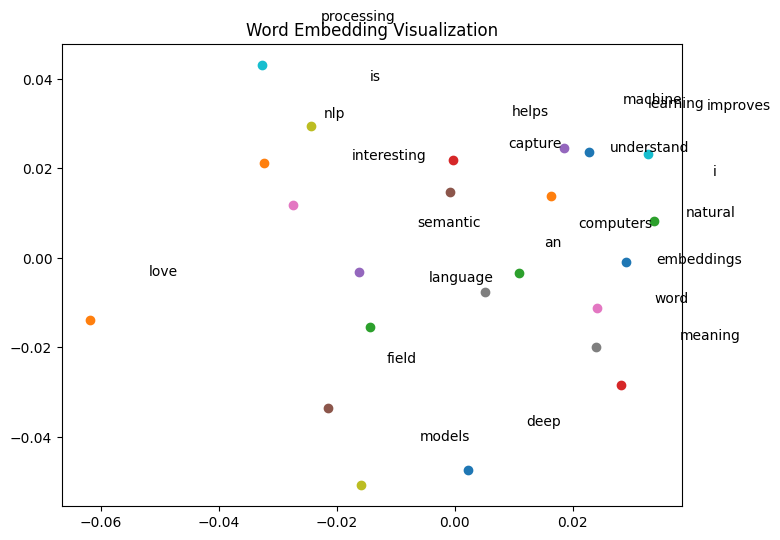

In [14]:
plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    plt.scatter(result[i,0], result[i,1])
    plt.text(result[i,0]+0.01, result[i,1]+0.01, word)

plt.title("Word Embedding Visualization")
plt.show()

## Key Concepts

Word Embeddings

Dense vector representations where semantic meaning is captured in numbers.

Example:

king - man + woman ≈ queen

This is why embeddings outperform:

- Bag of Words

- TF-IDF